### **Synthetic Data Generation for Dual-Visit Service Logistics (with Time-Dependent Travel Times)**

**Project:**
This project focuses on creating realistic synthetic datasets for a home-healthcare routing problem. It combines three challenging features:

1. **Dual visits** — each patient must be visited twice a day with a required time gap between visits
2. **Time-dependent travel** — travel times change during the day (e.g., rush-hour effects depending on road type)
3. **Time windows** — each visit has its own allowed time range, with dependencies between the two visits

**Deliverables:**

* A data generator that creates structured benchmark datasets (in JSON and CSV formats)
* A system to measure problem difficulty (Easy / Medium / Hard / Very Hard)
* Machine learning models to learn spatial and temporal patterns (comparing GMM ablation with a KDE baseline)
* A benchmark suite with at least 40 realistic problem instances and supporting statistics

In [1]:
import numpy as np, scipy, sklearn, matplotlib, networkx, json
print(f"numpy {np.__version__} | scipy {scipy.__version__} | "
      f"sklearn {sklearn.__version__} | networkx {networkx.__version__}")

import math
import matplotlib.pyplot as plt
import networkx as nx
from dataclasses import dataclass, asdict, field
from typing import List, Tuple, Dict, Optional
from collections import defaultdict
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.neighbors import KernelDensity

plt.rcParams["figure.dpi"] = 110
np.random.seed(0)
print("Setup complete.")

numpy 2.0.2 | scipy 1.16.3 | sklearn 1.6.1 | networkx 3.6.1
Setup complete.


## 1. City Generator

Instead of using a simple random graph,Created a more realistic synthetic city with:
- **Urban cores**  
  Dense central areas (e.g., business districts) with many intersections  
- **Density falloff**  
  Lower density as we move toward the outskirts  
- **Two-tier road network**  
  - **Arterial roads:** faster, fewer, and more affected by rush-hour traffic  
  - **Local roads:** slower but more densely connected  
- **Guaranteed connectivity**  
  All parts of the city are reachable  

In [2]:
@dataclass
class City:
    n_nodes: int
    coords: np.ndarray
    urban_cores: np.ndarray
    core_weights: np.ndarray
    graph: nx.Graph
    width_km: float
    height_km: float


def generate_city(n_nodes=120, n_cores=3, width_km=15.0, height_km=15.0,
                  arterial_fraction=0.25, seed=42):
    rng = np.random.default_rng(seed)

    # Urban cores
    margin = 0.2
    cores = rng.uniform(low=[margin*width_km, margin*height_km],
                        high=[(1-margin)*width_km, (1-margin)*height_km],
                        size=(n_cores, 2))
    core_weights = rng.uniform(0.5, 1.5, size=n_cores)
    core_weights = core_weights / core_weights.sum()

    # Intersection coords: mixture around cores + uniform background
    coords = []
    n_bg = int(0.15 * n_nodes)
    n_cluster = n_nodes - n_bg
    counts = rng.multinomial(n_cluster, core_weights)
    for k in range(n_cores):
        samples = rng.normal(loc=cores[k], scale=[1.8, 1.8], size=(counts[k], 2))
        coords.append(samples)
    bg = rng.uniform(low=[0,0], high=[width_km, height_km], size=(n_bg, 2))
    coords.append(bg)
    coords = np.vstack(coords)
    coords[:, 0] = np.clip(coords[:, 0], 0, width_km)
    coords[:, 1] = np.clip(coords[:, 1], 0, height_km)

    # Road network
    G = nx.Graph()
    for i, (x, y) in enumerate(coords):
        G.add_node(i, pos=(float(x), float(y)))

    LOCAL_SPEED, ARTERIAL_SPEED = 35.0, 60.0
    k_local, local_radius = 4, 2.5

    # Local roads: k-nearest within radius
    for i in range(n_nodes):
        d = np.linalg.norm(coords - coords[i], axis=1)
        nearest = np.argsort(d)[1:k_local+1]
        for j in nearest:
            dij = float(d[j])
            if dij <= local_radius and not G.has_edge(i, int(j)):
                G.add_edge(i, int(j), length_km=dij,
                           base_time=dij/LOCAL_SPEED, road_class="local")

    # Arterial backbone: connect cores
    core_nodes = [int(np.argmin(np.linalg.norm(coords - c, axis=1))) for c in cores]
    for i in range(len(core_nodes)):
        for j in range(i+1, len(core_nodes)):
            u, v = core_nodes[i], core_nodes[j]
            try:
                path = nx.shortest_path(G, u, v, weight="length_km")
                for a, b in zip(path[:-1], path[1:]):
                    G[a][b]["road_class"] = "arterial"
                    G[a][b]["base_time"] = G[a][b]["length_km"] / ARTERIAL_SPEED
            except nx.NetworkXNoPath:
                dij = float(np.linalg.norm(coords[u] - coords[v]))
                G.add_edge(u, v, length_km=dij, base_time=dij/ARTERIAL_SPEED,
                           road_class="arterial")

    # Upgrade longest locals to hit target arterial fraction
    target = int(arterial_fraction * G.number_of_edges())
    current = sum(1 for _,_,d in G.edges(data=True) if d["road_class"]=="arterial")
    if current < target:
        locals_list = [(u,v,d["length_km"]) for u,v,d in G.edges(data=True)
                       if d["road_class"]=="local"]
        locals_list.sort(key=lambda x: -x[2])
        for u, v, L in locals_list[:target - current]:
            G[u][v]["road_class"] = "arterial"
            G[u][v]["base_time"] = L / ARTERIAL_SPEED

    # Connectivity guarantee
    if not nx.is_connected(G):
        comps = list(nx.connected_components(G))
        for a, b in zip(comps[:-1], comps[1:]):
            best, best_d = None, math.inf
            for u in a:
                for v in b:
                    d = float(np.linalg.norm(coords[u] - coords[v]))
                    if d < best_d:
                        best_d, best = d, (u, v)
            if best:
                u, v = best
                G.add_edge(u, v, length_km=best_d,
                           base_time=best_d/ARTERIAL_SPEED, road_class="arterial")

    return City(n_nodes=n_nodes, coords=coords, urban_cores=cores,
                core_weights=core_weights, graph=G,
                width_km=width_km, height_km=height_km)

print("City generator ready.")

City generator ready.


## 2. Time-dependent traffic model

**Two peaks** (morning 8 AM, evening 6 PM). Arterials feel rush more strongly than local roads. Weekends have muted peaks. A small night-time discount reflects empty roads after 11 PM.

In [4]:
def congestion_multiplier(t_hours, road_class="local", weekday=True,
                          peak_am=1.6, peak_pm=1.9):
    t = t_hours % 24.0
    scale = 1.3 if road_class == "arterial" else 1.0
    if not weekday:
        scale *= 0.6
    morning = peak_am * scale * math.exp(-((t - 8.0)**2) / 1.5)
    evening = peak_pm * scale * math.exp(-((t - 18.0)**2) / 2.0)
    night_discount = 0.0
    if 23.0 <= t or t <= 5.0:
        night_discount = -0.15 * math.exp(-(((t - 24.0)%24.0 - 2.0)**2) / 8.0)
    return 1.0 + morning + evening + night_discount


def edge_travel_time(city, u, v, depart_hours, weekday=True):
    if not city.graph.has_edge(u, v):
        return math.inf
    d = city.graph[u][v]
    return d["base_time"] * congestion_multiplier(depart_hours, d["road_class"], weekday)


def precompute_base_distances(city):
    return dict(nx.all_pairs_dijkstra_path_length(city.graph, weight="base_time"))


def approx_travel_time(dist_base, u, v, depart_hours, weekday=True):
    """Standard VRP approximation: base-time shortest path × departure-hour multiplier."""
    if u == v:
        return 0.0
    base = dist_base[u].get(v, math.inf)
    if math.isinf(base):
        return math.inf
    mult = 0.5 * (congestion_multiplier(depart_hours, "arterial", weekday)
                + congestion_multiplier(depart_hours, "local", weekday))
    return base * mult


print("Traffic model ready.")

Traffic model ready.


## 3. Patient generator

Realistic features:
- **Non-uniform spatial distribution** — patients cluster near urban cores (demographic realism)
- **Log-normal service times** (real healthcare data shows right-skew)
- **Dual visits** — separate time windows for visit 1 (morning) and visit 2 (afternoon)
- **Gap constraints** — min/max hours between visits (e.g., morning medication, afternoon follow-up)
- **Priority levels** — 70% normal, 25% high, 5% urgent

In [5]:
@dataclass
class Patient:
    id: int
    node: int
    coords: Tuple[float, float]
    service_time_1: float
    service_time_2: float
    tw1_start: float
    tw1_end: float
    tw2_start: float
    tw2_end: float
    min_gap: float
    max_gap: float
    priority: int
    visit2_depends_on_visit1: bool = True


def generate_patients(city, n_patients, elderly_bias=0.7, tightness=0.5, seed=0):
    rng = np.random.default_rng(seed)

    # Spatial: probability proportional to proximity to weighted cores
    n_cores = city.urban_cores.shape[0]
    core_w = city.core_weights.copy()
    if elderly_bias > 0:
        elderly_core = rng.integers(0, n_cores)
        core_w[elderly_core] *= (1 + 2*elderly_bias)
        core_w /= core_w.sum()

    scores = np.zeros(city.n_nodes)
    for k in range(n_cores):
        d = np.linalg.norm(city.coords - city.urban_cores[k], axis=1)
        scores += core_w[k] * np.exp(-d / 2.0)
    scores += 0.05 * scores.max()
    scores /= scores.sum()
    patient_nodes = rng.choice(city.n_nodes, size=n_patients, replace=False, p=scores)

    # Service times: log-normal
    st1 = np.clip(rng.lognormal(-0.9, 0.4, n_patients), 0.15, 1.5)
    st2 = np.clip(rng.lognormal(-0.8, 0.45, n_patients), 0.15, 1.8)

    # Time windows: tightness controls width
    w_wide, w_tight = 4.0, 1.5
    w1_width = w_wide - (w_wide - w_tight) * tightness
    w2_width = w1_width * 0.9
    min_gap = 3.5 + 1.5 * tightness
    max_gap = 6.5 - 0.5 * tightness

    priorities = rng.choice([1,2,3], size=n_patients, p=[0.70, 0.25, 0.05])

    patients = []
    for i in range(n_patients):
        tw1s = float(rng.uniform(8.0, 14.0 - w1_width))
        tw1e = tw1s + float(rng.uniform(w1_width*0.8, w1_width))
        earliest_v2 = tw1e + min_gap
        latest_v2 = min(20.0 - w2_width, tw1s + max_gap + w2_width)
        if latest_v2 < earliest_v2:
            latest_v2 = earliest_v2 + 0.1
        tw2s = float(rng.uniform(earliest_v2, latest_v2))
        tw2e = min(20.0, tw2s + float(rng.uniform(w2_width*0.8, w2_width)))
        node = int(patient_nodes[i])
        patients.append(Patient(
            id=i, node=node,
            coords=(float(city.coords[node, 0]), float(city.coords[node, 1])),
            service_time_1=float(st1[i]), service_time_2=float(st2[i]),
            tw1_start=tw1s, tw1_end=tw1e, tw2_start=tw2s, tw2_end=tw2e,
            min_gap=float(min_gap), max_gap=float(max_gap),
            priority=int(priorities[i]),
        ))
    return patients


print("Patient generator ready.")

Patient generator ready.


## 4. Instance assembly + difficulty scoring

**Difficulty components** (all normalized to [0,1]):
1. **Size** — more patients = harder
2. **TW tightness** — narrower windows = harder
3. **Dual coupling** — tighter gap window = harder
4. **Traffic exposure** — fraction of patient windows overlapping rush hours
5. **Spatial dispersion** — patients far from depot = harder

Weighted sum → classification into Easy / Medium / Hard / Very Hard.

In [17]:
@dataclass
class Instance:
    instance_id: str
    city: City
    depot_node: int
    patients: List[Patient]
    n_vehicles: int
    day_start: float
    day_end: float
    weekday: bool
    generator_config: Dict = field(default_factory=dict)
    difficulty_score: Optional[float] = None
    difficulty_class: Optional[str] = None


def build_instance(instance_id, n_nodes=120, n_patients=25, n_vehicles=5,
                   n_cores=3, tightness=0.5, weekday=True, seed=0):
    city = generate_city(n_nodes=n_nodes, n_cores=n_cores, seed=seed)
    strongest = np.argmax(city.core_weights)
    d = np.linalg.norm(city.coords - city.urban_cores[strongest], axis=1)
    depot_node = int(np.argmin(d))
    patients = generate_patients(city, n_patients=n_patients,
                                 tightness=tightness, seed=seed+1)
    patients = [p for p in patients if p.node != depot_node]
    for i, p in enumerate(patients):
        p.id = i
    cfg = dict(n_nodes=n_nodes, n_patients=n_patients, n_vehicles=n_vehicles,
               n_cores=n_cores, tightness=tightness, weekday=weekday, seed=seed)
    return Instance(instance_id=instance_id, city=city, depot_node=depot_node,
                    patients=patients, n_vehicles=n_vehicles,
                    day_start=8.0, day_end=20.0, weekday=weekday,
                    generator_config=cfg)


def compute_difficulty(inst, dist_base=None):
    if dist_base is None:
        dist_base = precompute_base_distances(inst.city)
    P = inst.patients
    n = len(P)

    size_factor = min(1.0, n / 60.0)
    widths = np.array([p.tw1_end-p.tw1_start for p in P] +
                      [p.tw2_end-p.tw2_start for p in P])
    tw_tightness = np.clip((4.0 - widths.mean())/(4.0 - 1.5), 0, 1)
    gap_windows = np.array([p.max_gap - p.min_gap for p in P])
    dual_coupling = np.clip((3.0 - gap_windows.mean())/3.0, 0, 1)

    def overlap_frac(s, e, rs, re):
        o = max(0.0, min(e, re) - max(s, rs))
        return o / max(1e-6, e - s)
    exposures = []
    for p in P:
        e1 = overlap_frac(p.tw1_start, p.tw1_end, 7, 9) + \
             overlap_frac(p.tw1_start, p.tw1_end, 17, 19)
        e2 = overlap_frac(p.tw2_start, p.tw2_end, 7, 9) + \
             overlap_frac(p.tw2_start, p.tw2_end, 17, 19)
        exposures.append(0.5*(e1+e2))
    traffic_exposure = float(np.mean(exposures))

    depot = inst.depot_node
    mean_d = float(np.mean([dist_base[depot][p.node] for p in P]))
    city_diam = max(dist_base[depot].values())
    spatial_dispersion = min(1.0, mean_d / city_diam * 1.5)

    weights = {"size":0.15, "tw":0.30, "dual":0.25, "traffic":0.20, "spatial":0.10}
    components = {"size":size_factor, "tw":tw_tightness, "dual":dual_coupling,
                  "traffic":traffic_exposure, "spatial":spatial_dispersion}
    score = sum(weights[k]*components[k] for k in weights)

    if   score < 0.30: cls = "Easy"
    elif score < 0.45: cls = "Medium"
    elif score < 0.60: cls = "Hard"
    else:              cls = "Very Hard"

    inst.difficulty_score = float(score)
    inst.difficulty_class = cls
    return float(score), cls, components


print("Difficulty scoring ready.")

Difficulty scoring ready.


## 5. Baseline dual-visit solver

A simple greedy solver — **NOT the focus of the project**.Used it to validate that our difficulty score is meaningful: if "Hard" instances really are harder, a solver should struggle on them more than on "Easy" ones.

Strategy: two-pass greedy insertion. Pass 1 assigns visit 1 to vehicles. Pass 2 assigns visit 2 respecting min/max gap from visit 1.

In [7]:
@dataclass
class SolverResult:
    total_travel_time: float
    n_fully_served: int
    n_partially_served: int
    n_unserved: int
    routes: List[List[dict]]


def greedy_dual_solver(inst, dist_base, gap_slack=0.0):
    P = inst.patients
    weekday = inst.weekday
    status = [0]*len(P)
    v1_time = [None]*len(P)
    routes = [[] for _ in range(inst.n_vehicles)]
    total_tt = 0.0

    # Pass 1: visit 1 assignment
    for veh in range(inst.n_vehicles):
        t = inst.day_start
        current = inst.depot_node
        while True:
            best, best_arrive = None, float("inf")
            for i, p in enumerate(P):
                if status[i] != 0: continue
                tt = approx_travel_time(dist_base, current, p.node, t, weekday)
                arrive = max(t+tt, p.tw1_start)
                if arrive > p.tw1_end: continue
                if arrive + p.service_time_1 + 4.0 > inst.day_end: continue
                if arrive < best_arrive:
                    best_arrive, best = arrive, i
            if best is None: break
            p = P[best]
            tt = approx_travel_time(dist_base, current, p.node, t, weekday)
            total_tt += tt
            t = best_arrive
            routes[veh].append({"patient":best,"visit":1,"arrive":t,
                                "depart":t+p.service_time_1,"node":p.node})
            v1_time[best] = t
            t += p.service_time_1
            current = p.node
            status[best] = 1

    # Pass 2: visit 2
    for veh in range(inst.n_vehicles):
        if not routes[veh]: continue
        t = routes[veh][-1]["depart"]
        current = routes[veh][-1]["node"]
        while True:
            best, best_arrive = None, float("inf")
            for i, p in enumerate(P):
                if status[i] != 1: continue
                earliest = v1_time[i] + p.min_gap
                latest = v1_time[i] + p.max_gap
                wait_t = max(t, earliest)
                tt = approx_travel_time(dist_base, current, p.node, wait_t, weekday)
                arrive = max(wait_t+tt, p.tw2_start)
                if arrive > p.tw2_end: continue
                if arrive > latest + gap_slack: continue
                if arrive + p.service_time_2 > inst.day_end: continue
                if arrive < best_arrive:
                    best_arrive, best = arrive, i
            if best is None: break
            p = P[best]
            wait_t = max(t, v1_time[best]+p.min_gap)
            tt = approx_travel_time(dist_base, current, p.node, wait_t, weekday)
            total_tt += tt
            t = best_arrive
            routes[veh].append({"patient":best,"visit":2,"arrive":t,
                                "depart":t+p.service_time_2,"node":p.node})
            t += p.service_time_2
            current = p.node
            status[best] = 2

    return SolverResult(total_travel_time=total_tt,
                        n_fully_served=sum(1 for s in status if s==2),
                        n_partially_served=sum(1 for s in status if s==1),
                        n_unserved=sum(1 for s in status if s==0),
                        routes=routes)


def success_rate(result, n_patients):
    return result.n_fully_served / max(1, n_patients)


print("Solver ready.")

Solver ready.


## 6. Visualization helpers

In [8]:
def plot_city_network(city, depot_node=None, patients=None, ax=None, title="City"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    pos = {i: city.coords[i] for i in city.graph.nodes()}
    arterial = [(u,v) for u,v,d in city.graph.edges(data=True) if d["road_class"]=="arterial"]
    local = [(u,v) for u,v,d in city.graph.edges(data=True) if d["road_class"]=="local"]
    nx.draw_networkx_edges(city.graph, pos, edgelist=local, ax=ax,
                           edge_color="#cbd5e1", width=0.8, alpha=0.7)
    nx.draw_networkx_edges(city.graph, pos, edgelist=arterial, ax=ax,
                           edge_color="#475569", width=1.8, alpha=0.9)
    nx.draw_networkx_nodes(city.graph, pos, ax=ax, node_size=8, node_color="#94a3b8")
    for cx, cy in city.urban_cores:
        ax.scatter(cx, cy, marker="*", s=300, color="#fbbf24",
                   edgecolor="black", linewidth=1, zorder=5)
    if patients:
        colors = {1:"#60a5fa", 2:"#f59e0b", 3:"#dc2626"}
        for p in patients:
            ax.scatter(p.coords[0], p.coords[1], s=50,
                       color=colors.get(p.priority,"#60a5fa"),
                       edgecolor="white", linewidth=0.8, zorder=4)
    if depot_node is not None:
        dx, dy = city.coords[depot_node]
        ax.scatter(dx, dy, marker="s", s=200, color="#dc2626",
                   edgecolor="black", linewidth=1.5, zorder=6)
    ax.set_xlabel("X (km)"); ax.set_ylabel("Y (km)")
    ax.set_title(title); ax.set_aspect("equal"); ax.grid(alpha=0.3)
    return ax


def plot_congestion_profile(ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    hrs = np.linspace(0, 24, 500)
    ax.plot(hrs, [congestion_multiplier(h,"arterial",True) for h in hrs],
            label="Arterial weekday", color="#dc2626", lw=2)
    ax.plot(hrs, [congestion_multiplier(h,"local",True) for h in hrs],
            label="Local weekday", color="#2563eb", lw=2)
    ax.plot(hrs, [congestion_multiplier(h,"arterial",False) for h in hrs],
            label="Arterial weekend", color="#dc2626", lw=1.5, ls="--", alpha=0.6)
    ax.axhline(1.0, color="gray", ls=":", lw=1)
    ax.set_xlabel("Hour of day"); ax.set_ylabel("Travel-time multiplier")
    ax.set_title("Time-dependent congestion")
    ax.set_xticks(range(0, 25, 3)); ax.legend(); ax.grid(alpha=0.3)
    return ax


def plot_time_windows(patients, ax=None, max_show=30):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, max(4, min(len(patients), max_show)*0.3)))
    show = patients[:max_show]
    for i, p in enumerate(show):
        ax.barh(i, p.tw1_end-p.tw1_start, left=p.tw1_start, height=0.35,
                color="#2563eb", alpha=0.8, label="Visit 1" if i==0 else "")
        ax.barh(i, p.tw2_end-p.tw2_start, left=p.tw2_start, height=0.35,
                color="#f59e0b", alpha=0.8, label="Visit 2" if i==0 else "")
    ax.set_xlabel("Hour of day"); ax.set_ylabel("Patient id")
    ax.set_title(f"Time windows (first {len(show)} patients)")
    ax.legend(loc="upper right"); ax.set_xlim(7.5, 20.5); ax.grid(alpha=0.3, axis="x")
    return ax


print("Plots ready.")

Plots ready.


## 7. Demo: generate and visualize a single instance

Instance demo_001
  City: 150 nodes, 366 edges
  Road network: 94 arterials, 272 locals
  Patients: 30  Depot: node 78

Difficulty score: 0.457 (Medium)
  Components: {'size': 0.5, 'tw': np.float64(0.666464496835028), 'dual': np.float64(0.3333333333333333), 'traffic': 0.3866914337301194, 'spatial': 0.21885855703932283}

Greedy solver: 13/30 fully served (success rate 43.3%)
  Partial: 17  Unserved: 0
  Total travel time: 5.54 hours


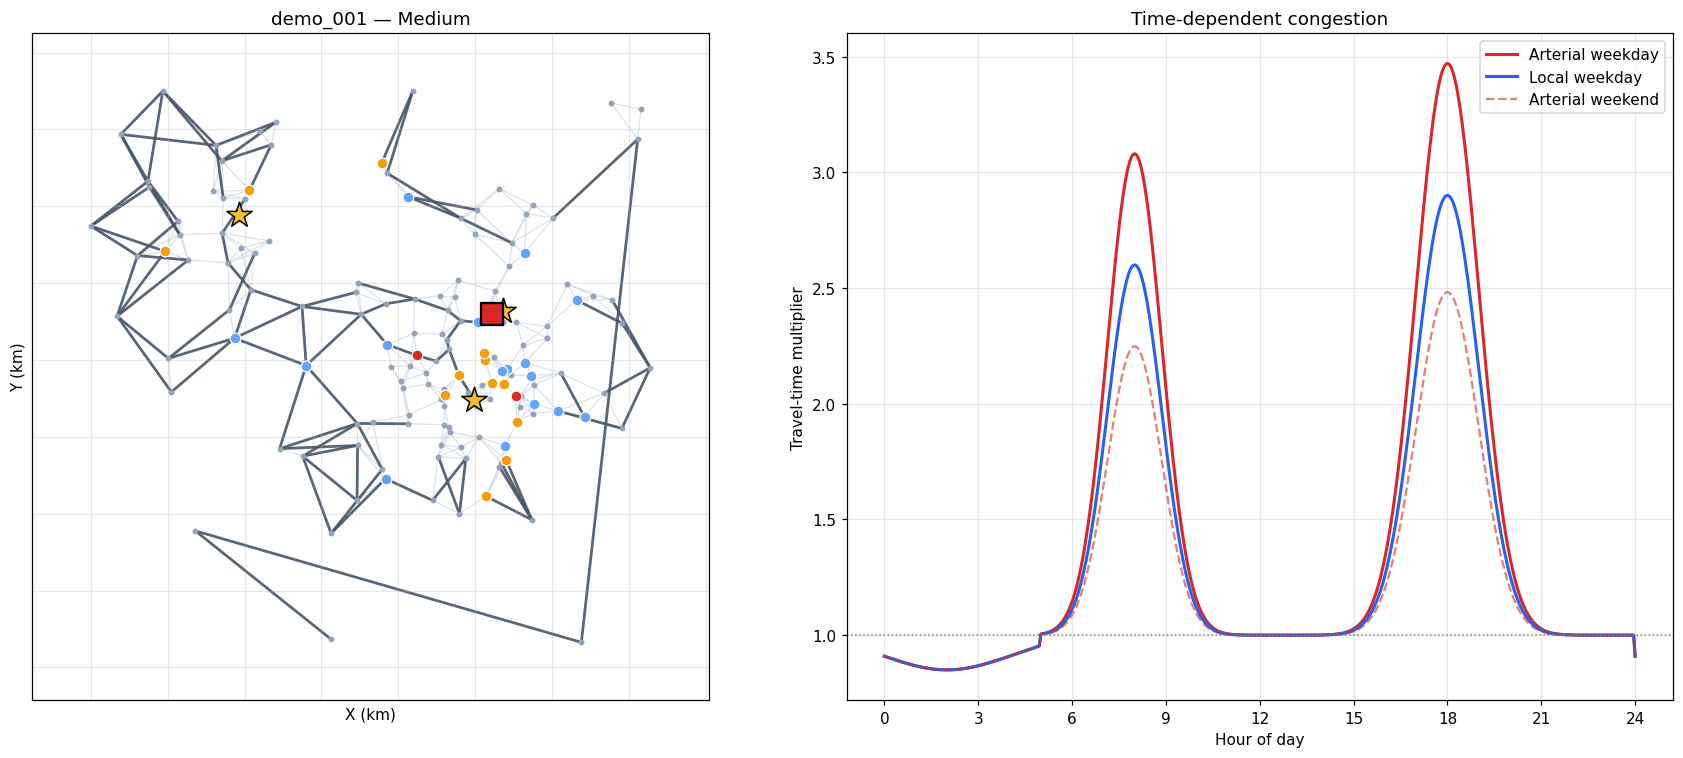

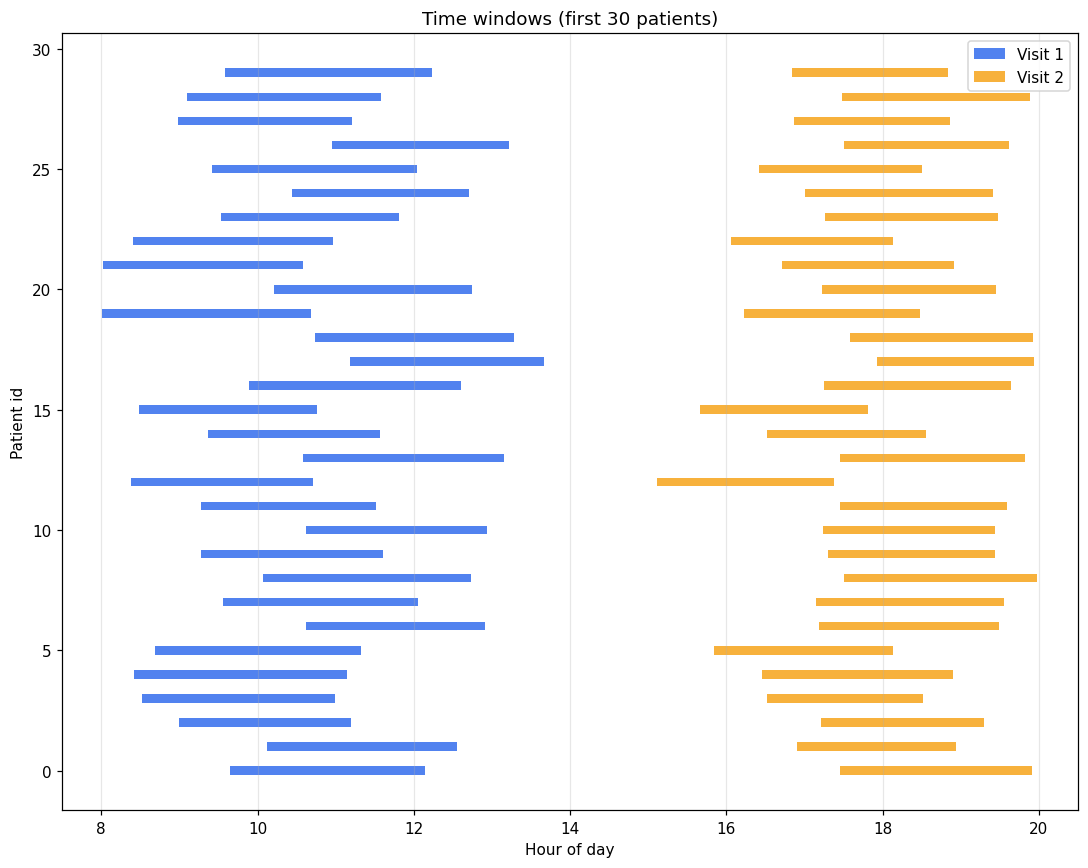

In [9]:
inst = build_instance("demo_001", n_nodes=150, n_patients=30,
                      n_vehicles=5, tightness=0.5, seed=42)
dist = precompute_base_distances(inst.city)
score, cls, components = compute_difficulty(inst, dist)
res = greedy_dual_solver(inst, dist)

print(f"Instance {inst.instance_id}")
print(f"  City: {inst.city.n_nodes} nodes, {inst.city.graph.number_of_edges()} edges")
arterials = sum(1 for _,_,d in inst.city.graph.edges(data=True) if d['road_class']=='arterial')
print(f"  Road network: {arterials} arterials, "
      f"{inst.city.graph.number_of_edges()-arterials} locals")
print(f"  Patients: {len(inst.patients)}  Depot: node {inst.depot_node}")
print(f"\nDifficulty score: {score:.3f} ({cls})")
print(f"  Components: {components}")
print(f"\nGreedy solver: {res.n_fully_served}/{len(inst.patients)} fully served "
      f"(success rate {100*success_rate(res, len(inst.patients)):.1f}%)")
print(f"  Partial: {res.n_partially_served}  Unserved: {res.n_unserved}")
print(f"  Total travel time: {res.total_travel_time:.2f} hours")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_city_network(inst.city, depot_node=inst.depot_node,
                  patients=inst.patients, ax=axes[0],
                  title=f"{inst.instance_id} — {cls}")
plot_congestion_profile(ax=axes[1])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
plot_time_windows(inst.patients, ax=ax)
plt.tight_layout()
plt.show()

## 8. Export: JSON + CSV benchmark format

The deliverable specifies "standardized benchmarks." JSON is the full-fidelity format (everything needed to reconstruct). CSV is for quick inspection in Excel or for solvers that prefer tabular input.

In [10]:
def instance_to_dict(inst):
    edges = [{"u":int(u),"v":int(v),
              "length_km":round(d["length_km"],4),
              "base_time_hr":round(d["base_time"],5),
              "road_class":d["road_class"]}
             for u,v,d in inst.city.graph.edges(data=True)]
    return {
        "instance_id": inst.instance_id,
        "difficulty": {"score": inst.difficulty_score, "class": inst.difficulty_class},
        "city": {
            "n_nodes": inst.city.n_nodes,
            "width_km": inst.city.width_km, "height_km": inst.city.height_km,
            "urban_cores": inst.city.urban_cores.tolist(),
            "coords_km": inst.city.coords.round(4).tolist(),
            "edges": edges,
        },
        "depot_node": inst.depot_node,
        "fleet": {"n_vehicles": inst.n_vehicles},
        "day": {"start": inst.day_start, "end": inst.day_end, "weekday": inst.weekday},
        "patients": [asdict(p) for p in inst.patients],
        "traffic_model": {"type":"gaussian_two_peak_with_road_class",
                          "morning_peak_hr":8.0, "evening_peak_hr":18.0,
                          "arterial_peak_scale":1.3, "weekend_peak_scale":0.6},
        "generator_config": inst.generator_config,
    }


def save_instance_json(inst, path):
    with open(path, "w") as f:
        json.dump(instance_to_dict(inst), f, indent=2)


# Demo export
import os, tempfile
os.makedirs("/content/benchmark_out", exist_ok=True)
save_instance_json(inst, "/content/benchmark_out/demo_001.json")
print(f"Written /content/benchmark_out/demo_001.json")

# CSV
import csv
p_rows = [{
    "instance_id":inst.instance_id, "patient_id":p.id, "node":p.node,
    "x_km":round(p.coords[0],4), "y_km":round(p.coords[1],4),
    "service_time_1_hr":round(p.service_time_1,3),
    "service_time_2_hr":round(p.service_time_2,3),
    "tw1_start":round(p.tw1_start,3), "tw1_end":round(p.tw1_end,3),
    "tw2_start":round(p.tw2_start,3), "tw2_end":round(p.tw2_end,3),
    "min_gap_hr":round(p.min_gap,2), "max_gap_hr":round(p.max_gap,2),
    "priority":p.priority,
} for p in inst.patients]

with open("/content/benchmark_out/demo_001_patients.csv","w",newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(p_rows[0].keys()))
    w.writeheader(); w.writerows(p_rows)
print(f"Written /content/benchmark_out/demo_001_patients.csv")

# Inspect the JSON
with open("/content/benchmark_out/demo_001.json") as f:
    data = json.load(f)
print("\nJSON structure (top-level keys):")
for k in data:
    print(f"  {k}")
print(f"\nPatient 0 entry: {data['patients'][0]}")

Written /content/benchmark_out/demo_001.json
Written /content/benchmark_out/demo_001_patients.csv

JSON structure (top-level keys):
  instance_id
  difficulty
  city
  depot_node
  fleet
  day
  patients
  traffic_model
  generator_config

Patient 0 entry: {'id': 0, 'node': 5, 'coords': [12.166178846616925, 6.671752890044627], 'service_time_1': 0.24917333995994964, 'service_time_2': 0.487425012234857, 'tw1_start': 9.650703616584234, 'tw1_end': 12.146631463294987, 'tw2_start': 17.45350869012491, 'tw2_end': 19.90927738219699, 'min_gap': 4.25, 'max_gap': 6.25, 'priority': 1, 'visit2_depends_on_visit1': True}


## 9. Difficulty validation experiment (research rigor)

Generated many instances across difficulty configurations, then run the greedy solver on each. **If the difficulty score is meaningful, solver success rate should correlate negatively with difficulty.**

This is the key empirical claim that elevates the project from "generator" to "validated benchmark suite."

Running 75 validation instances...
  15/75 done
  30/75 done
  45/75 done
  60/75 done
  75/75 done

Class         n_instances   mean_success      std
------------------------------------------------
Easy                   10         45.25%    6.58%
Medium                 35         39.81%    8.79%
Hard                   30         29.73%    9.77%

Correlation analysis:
  Pearson r = -0.580  (p = 5.06e-08)
  Spearman ρ = -0.596  (p = 1.66e-08)
  Negative correlation confirms difficulty score is empirically valid.


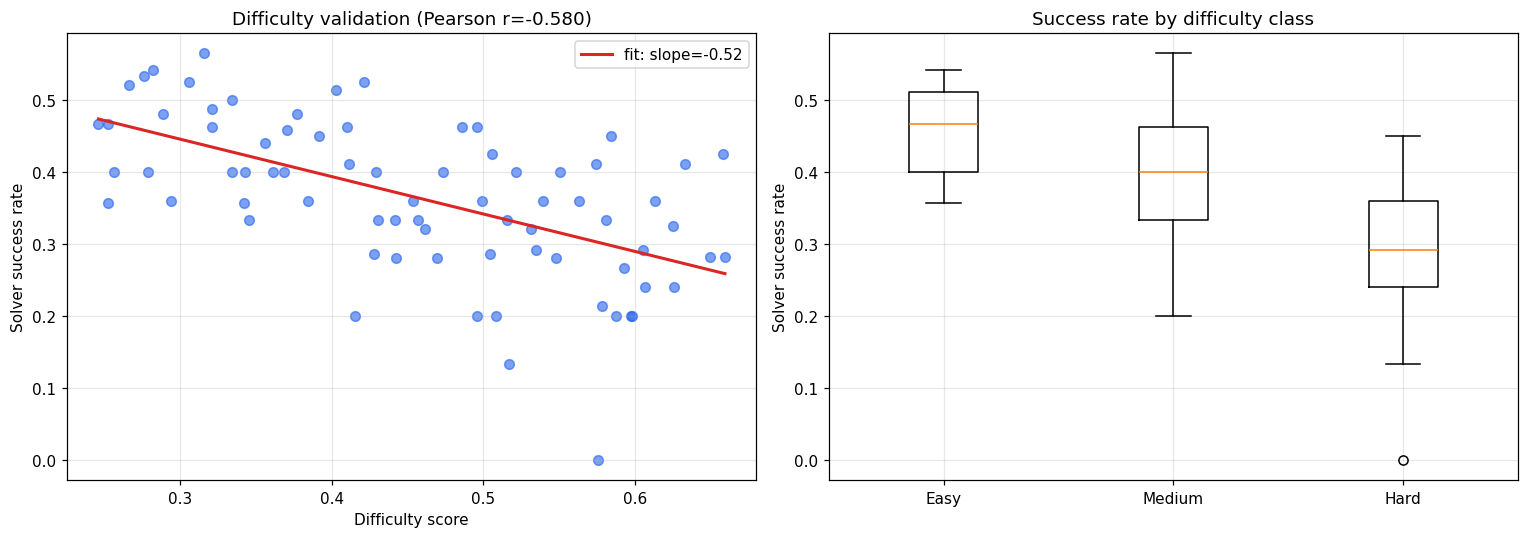

In [11]:
validation_results = []
configs = [(n, t, s) for n in [15, 25, 40]
                     for t in [0.1, 0.3, 0.5, 0.7, 0.9]
                     for s in range(5)]
print(f"Running {len(configs)} validation instances...")

for i, (n_pat, tightness, seed) in enumerate(configs):
    inst = build_instance(f'v_{n_pat}_{tightness}_{seed}',
                          n_nodes=120, n_patients=n_pat,
                          tightness=tightness, seed=seed)
    dist = precompute_base_distances(inst.city)
    score, cls, _ = compute_difficulty(inst, dist)
    res = greedy_dual_solver(inst, dist)
    rate = success_rate(res, len(inst.patients))
    validation_results.append({
        "n_pat": n_pat, "tightness": tightness, "seed": seed,
        "score": score, "class": cls, "rate": rate,
    })
    if (i+1) % 15 == 0:
        print(f"  {i+1}/{len(configs)} done")

# Aggregate
classes = ["Easy", "Medium", "Hard", "Very Hard"]
by_class = defaultdict(list)
for r in validation_results:
    by_class[r["class"]].append(r["rate"])

print(f"\n{'Class':<12} {'n_instances':>12} {'mean_success':>14} {'std':>8}")
print("-" * 48)
for c in classes:
    if by_class[c]:
        arr = np.array(by_class[c])
        print(f"{c:<12} {len(arr):>12} {arr.mean():>14.2%} {arr.std():>8.2%}")

scores = np.array([r["score"] for r in validation_results])
rates = np.array([r["rate"] for r in validation_results])
r_p, p_p = pearsonr(scores, rates)
r_s, p_s = spearmanr(scores, rates)
print(f"\nCorrelation analysis:")
print(f"  Pearson r = {r_p:.3f}  (p = {p_p:.2e})")
print(f"  Spearman ρ = {r_s:.3f}  (p = {p_s:.2e})")
print(f"  Negative correlation confirms difficulty score is empirically valid.")

# Scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(scores, rates, alpha=0.6, s=40, c="#2563eb")
z = np.polyfit(scores, rates, 1)
xs = np.linspace(scores.min(), scores.max(), 100)
axes[0].plot(xs, np.polyval(z, xs), color="#dc2626", lw=2,
             label=f"fit: slope={z[0]:.2f}")
axes[0].set_xlabel("Difficulty score"); axes[0].set_ylabel("Solver success rate")
axes[0].set_title(f"Difficulty validation (Pearson r={r_p:.3f})")
axes[0].legend(); axes[0].grid(alpha=0.3)

present_classes = [c for c in classes if by_class[c]]
axes[1].boxplot([by_class[c] for c in present_classes], tick_labels=present_classes)
axes[1].set_ylabel("Solver success rate")
axes[1].set_title("Success rate by difficulty class")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. ML pattern learning — GMM vs baseline ablation

**Setup:** fit spatial and temporal models to a "reference" patient dataset, then generate new synthetic patients and measure how similar they are to the reference distribution.

**Models compared:**
- **Baseline**: k-means + KDE (spatial), histogram sampling (temporal)
- **Advanced**: GMM with BIC-based component selection (spatial + temporal)

**Metrics:**
- **Sliced Wasserstein distance** (lower = more similar distributions)
- **Log-likelihood** of reference data under the fitted model (higher = better fit)

This ablation is the direct response to the brief's "ML models will be explored to learn and reproduce realistic spatial and temporal patterns."

In [12]:
class BaselineSpatialModel:
    def __init__(self, n_clusters=3, kde_bandwidth=0.8):
        self.n_clusters = n_clusters
        self.bandwidth = kde_bandwidth
    def fit(self, xy):
        self.kmeans = KMeans(n_clusters=self.n_clusters, n_init=10, random_state=0).fit(xy)
        self.kde = KernelDensity(bandwidth=self.bandwidth, kernel="gaussian").fit(xy)
        return self
    def sample(self, n, rng):
        return self.kde.sample(n, random_state=int(rng.integers(0, 1_000_000_000)))
    def log_likelihood(self, xy):
        return float(self.kde.score(xy))


class GMMSpatialModel:
    def __init__(self, max_components=8):
        self.max_components = max_components
    def fit(self, xy):
        best_bic, best = np.inf, None
        max_k = min(self.max_components, max(1, len(xy)//3))
        for k in range(1, max_k+1):
            try:
                g = GaussianMixture(n_components=k, covariance_type="full",
                                    random_state=0, n_init=3, reg_covar=1e-3).fit(xy)
                bic = g.bic(xy)
                if bic < best_bic: best_bic, best = bic, g
            except Exception: continue
        self.gmm = best
        return self
    def sample(self, n, rng):
        self.gmm.random_state = int(rng.integers(0, 1_000_000_000))
        s, _ = self.gmm.sample(n); return s
    def log_likelihood(self, xy):
        return float(self.gmm.score(xy))
    @property
    def n_components(self): return self.gmm.n_components


class BaselineTemporalModel:
    def __init__(self, bins=24): self.bins = bins
    def fit(self, x):
        self.hist, self.edges = np.histogram(x, bins=self.bins, density=True)
        return self
    def sample(self, n, rng):
        probs = self.hist / self.hist.sum()
        bins = rng.choice(len(probs), size=n, p=probs)
        return rng.uniform(self.edges[bins], self.edges[bins+1])


class GMMTemporalModel:
    def __init__(self, max_components=5): self.max_components = max_components
    def fit(self, x):
        X = x.reshape(-1,1)
        best_bic, best = np.inf, None
        for k in range(1, min(self.max_components, max(1, len(X)//3))+1):
            try:
                g = GaussianMixture(n_components=k, covariance_type="full",
                                    random_state=0, n_init=3, reg_covar=1e-3).fit(X)
                bic = g.bic(X)
                if bic < best_bic: best_bic, best = bic, g
            except Exception: continue
        self.gmm = best
        return self
    def sample(self, n, rng):
        self.gmm.random_state = int(rng.integers(0, 1_000_000_000))
        s, _ = self.gmm.sample(n); return s.flatten()


class LogNormalServiceTimeModel:
    def fit(self, x):
        self.shape, self.loc, self.scale = stats.lognorm.fit(x, floc=0)
        return self
    def sample(self, n, rng):
        u = rng.uniform(size=n)
        return stats.lognorm.ppf(u, self.shape, loc=self.loc, scale=self.scale)


def wasserstein_2d(a, b, n_proj=20, seed=0):
    rng = np.random.default_rng(seed)
    ds = []
    for _ in range(n_proj):
        theta = rng.uniform(0, 2*np.pi)
        dir_ = np.array([np.cos(theta), np.sin(theta)])
        ds.append(stats.wasserstein_distance(a @ dir_, b @ dir_))
    return float(np.mean(ds))


def wasserstein_1d(a, b):
    return float(stats.wasserstein_distance(a, b))


print("ML models ready.")

ML models ready.


Reference: 100 patients, 200 visit-start observations

Spatial GMM selected 2 components (BIC-optimal)
Temporal GMM selected 4 components

Metric                                       Baseline     Advanced
--------------------------------------------------------------------
Spatial sliced-Wasserstein ↓                   0.2787       0.2832
Spatial avg log-likelihood ↑                  -4.2812      -0.0446
Temporal 1-D Wasserstein ↓                     0.3496       0.1755

Service time fit:
  ref mean=0.457, gen mean=0.472
  ref std =0.204, gen std =0.208


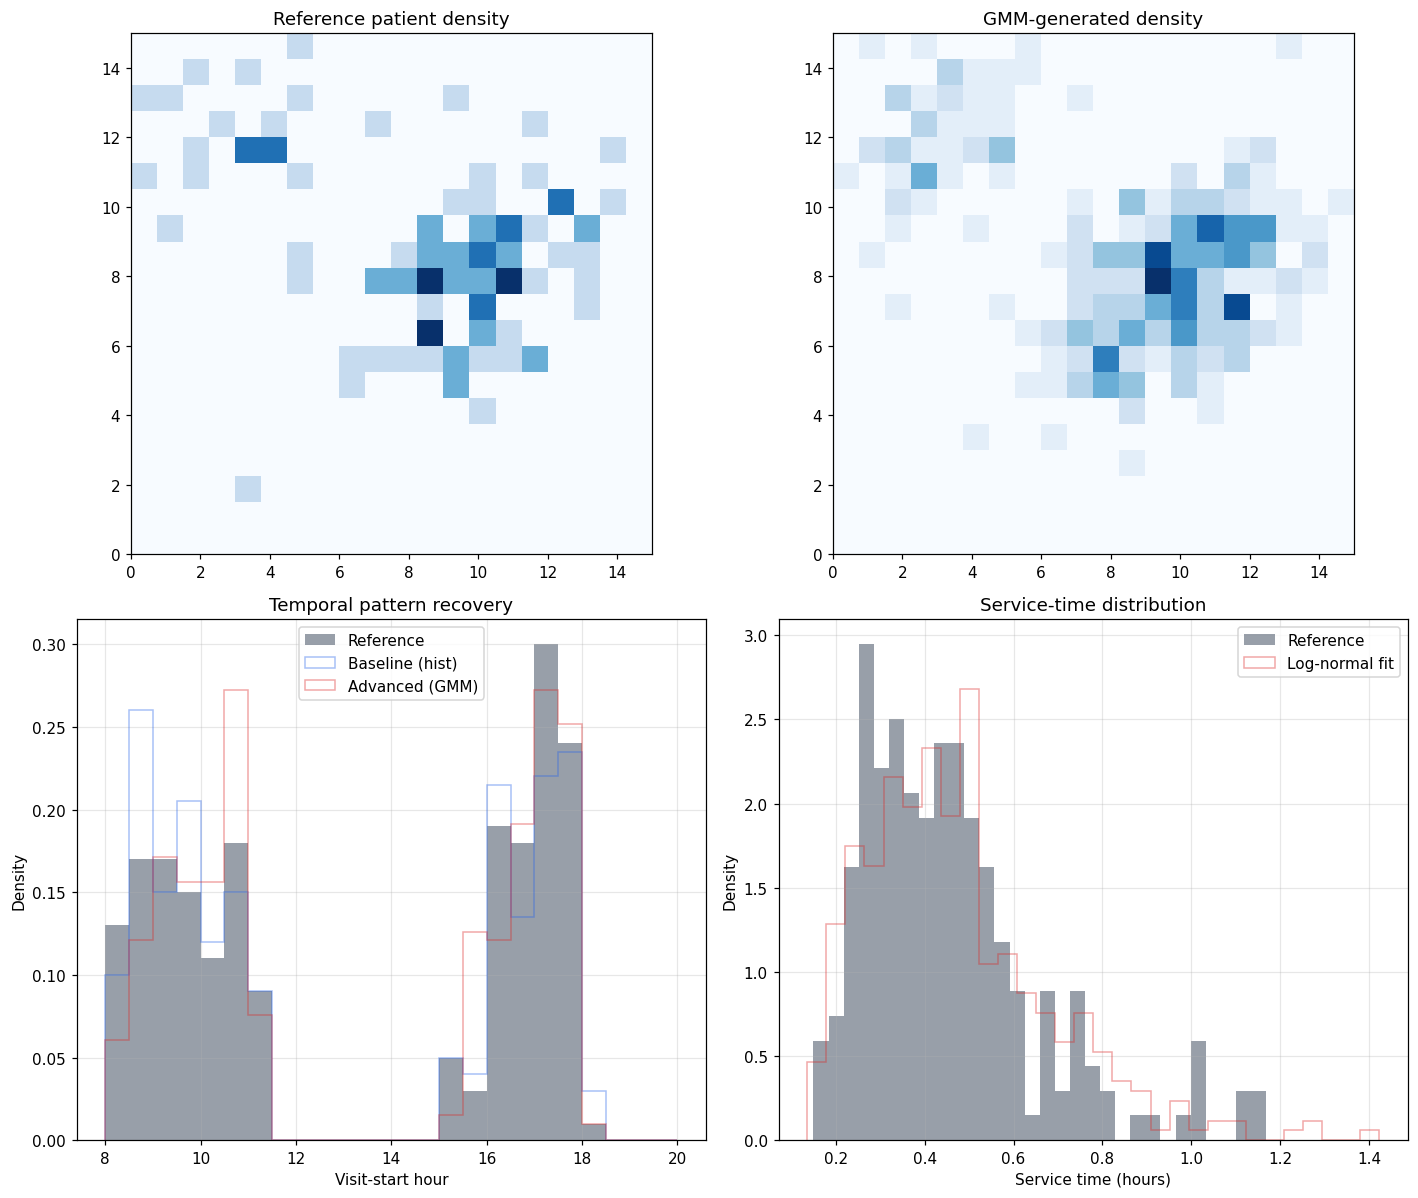

In [13]:
# Build a reference dataset: large single city with many patients
ref_city = generate_city(n_nodes=200, n_cores=3, seed=42)
ref_patients = generate_patients(ref_city, n_patients=100, tightness=0.5, seed=100)

ref_xy = np.array([p.coords for p in ref_patients])
ref_starts = np.concatenate([[p.tw1_start for p in ref_patients],
                             [p.tw2_start for p in ref_patients]])
ref_st = np.concatenate([[p.service_time_1 for p in ref_patients],
                         [p.service_time_2 for p in ref_patients]])
print(f"Reference: {len(ref_xy)} patients, {len(ref_starts)} visit-start observations")

# Fit
base_sp = BaselineSpatialModel(n_clusters=3, kde_bandwidth=0.8).fit(ref_xy)
gmm_sp = GMMSpatialModel(max_components=8).fit(ref_xy)
base_t = BaselineTemporalModel().fit(ref_starts)
gmm_t = GMMTemporalModel().fit(ref_starts)
ln_st = LogNormalServiceTimeModel().fit(ref_st)

print(f"\nSpatial GMM selected {gmm_sp.n_components} components (BIC-optimal)")
print(f"Temporal GMM selected {gmm_t.gmm.n_components} components")

# Generate synthetic
rng = np.random.default_rng(2024)
gen_base_xy = base_sp.sample(300, rng)
gen_gmm_xy = gmm_sp.sample(300, rng)
gen_base_t = base_t.sample(400, rng)
gen_gmm_t = gmm_t.sample(400, rng)
gen_st = ln_st.sample(400, rng)

# Metrics
w_base_sp = wasserstein_2d(ref_xy, gen_base_xy, seed=1)
w_gmm_sp = wasserstein_2d(ref_xy, gen_gmm_xy, seed=1)
ll_base_sp = base_sp.log_likelihood(ref_xy) / len(ref_xy)
ll_gmm_sp = gmm_sp.log_likelihood(ref_xy) / len(ref_xy)
w_base_t = wasserstein_1d(ref_starts, gen_base_t)
w_gmm_t = wasserstein_1d(ref_starts, gen_gmm_t)

print(f"\n{'Metric':<40} {'Baseline':>12} {'Advanced':>12}")
print("-" * 68)
print(f"{'Spatial sliced-Wasserstein ↓':<40} {w_base_sp:>12.4f} {w_gmm_sp:>12.4f}")
print(f"{'Spatial avg log-likelihood ↑':<40} {ll_base_sp:>12.4f} {ll_gmm_sp:>12.4f}")
print(f"{'Temporal 1-D Wasserstein ↓':<40} {w_base_t:>12.4f} {w_gmm_t:>12.4f}")
print(f"\nService time fit:")
print(f"  ref mean={ref_st.mean():.3f}, gen mean={gen_st.mean():.3f}")
print(f"  ref std ={ref_st.std():.3f}, gen std ={gen_st.std():.3f}")

# Plots
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

# Row 1: spatial density comparison
bbox = (ref_city.width_km, ref_city.height_km)
axes[0,0].hist2d(ref_xy[:,0], ref_xy[:,1], bins=20, range=[[0,bbox[0]],[0,bbox[1]]], cmap="Blues")
axes[0,0].set_title("Reference patient density"); axes[0,0].set_aspect("equal")
axes[0,1].hist2d(gen_gmm_xy[:,0], gen_gmm_xy[:,1], bins=20, range=[[0,bbox[0]],[0,bbox[1]]], cmap="Blues")
axes[0,1].set_title("GMM-generated density"); axes[0,1].set_aspect("equal")

# Row 2: temporal comparison + service times
bins = np.arange(8, 20.5, 0.5)
axes[1,0].hist(ref_starts, bins=bins, alpha=0.5, density=True, label="Reference", color="#334155")
axes[1,0].hist(gen_base_t, bins=bins, alpha=0.4, density=True, label="Baseline (hist)",
               color="#2563eb", histtype="step", lw=2)
axes[1,0].hist(gen_gmm_t, bins=bins, alpha=0.4, density=True, label="Advanced (GMM)",
               color="#dc2626", histtype="step", lw=2)
axes[1,0].set_xlabel("Visit-start hour"); axes[1,0].set_ylabel("Density")
axes[1,0].set_title("Temporal pattern recovery"); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].hist(ref_st, bins=30, alpha=0.5, density=True, label="Reference", color="#334155")
axes[1,1].hist(gen_st, bins=30, alpha=0.4, density=True, label="Log-normal fit",
               color="#dc2626", histtype="step", lw=2)
axes[1,1].set_xlabel("Service time (hours)"); axes[1,1].set_ylabel("Density")
axes[1,1].set_title("Service-time distribution"); axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 11. Build the final benchmark suite

Generate a **standardized benchmark** of 40 instances spanning the full difficulty spectrum. This is the tangible deliverable a supervisor can download and evaluate their own solvers on.

In [18]:
import os, csv, json
os.makedirs("/content/benchmark_suite", exist_ok=True)

benchmark_configs = []
# 10 per difficulty class, varying size + tightness
for diff_target, configs in [
    ("Easy", [(10, 0.1, s) for s in range(5)] + [(15, 0.2, s) for s in range(5)]),
    ("Medium", [(20, 0.3, s) for s in range(5)] + [(25, 0.5, s) for s in range(5)]),
    ("Hard", [(30, 0.6, s) for s in range(5)] + [(35, 0.7, s) for s in range(5)]),
    ("Very Hard", [(45, 0.9, s) for s in range(5)] + [(50, 0.95, s) for s in range(5)]),
]:
    benchmark_configs.extend(configs)

print(f"Building {len(benchmark_configs)} benchmark instances...")
manifest = []
for i, (n_pat, tight, seed) in enumerate(benchmark_configs):
    inst_id = f"bench_{i:03d}"
    inst = build_instance(inst_id, n_nodes=120, n_patients=n_pat,
                          tightness=tight, seed=seed)
    dist = precompute_base_distances(inst.city)
    score, cls, comps = compute_difficulty(inst, dist)
    res = greedy_dual_solver(inst, dist)
    rate = success_rate(res, len(inst.patients))
    save_instance_json(inst, f"/content/benchmark_suite/{inst_id}.json")
    manifest.append({
        "instance_id": inst_id, "class": cls, "score": round(score, 3),
        "n_patients": len(inst.patients), "n_vehicles": inst.n_vehicles,
        "n_city_nodes": inst.city.n_nodes,
        "n_edges": inst.city.graph.number_of_edges(),
        "tightness_param": tight, "seed": seed,
        "greedy_success_rate": round(rate, 3),
        "greedy_travel_time_hr": round(res.total_travel_time, 3),
    })

# Save manifest
with open("/content/benchmark_suite/manifest.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(manifest[0].keys()))
    w.writeheader(); w.writerows(manifest)

with open("/content/benchmark_suite/manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print(f"\n{len(manifest)} instances written to /content/benchmark_suite/")
print(f"Manifest: /content/benchmark_suite/manifest.csv")

# Distribution of difficulty classes in the final suite
classes = ["Easy", "Medium", "Hard", "Very Hard"]
dist_counts = {c: sum(1 for m in manifest if m["class"] == c) for c in classes}
print(f"\nFinal difficulty distribution:")
for c in classes:
    print(f"  {c:<12} {dist_counts[c]:>3} instances")

Building 40 benchmark instances...

40 instances written to /content/benchmark_suite/
Manifest: /content/benchmark_suite/manifest.csv

Final difficulty distribution:
  Easy           8 instances
  Medium         8 instances
  Hard          14 instances
  Very Hard     10 instances


First 10 benchmark instances:
instance_id  class  score  n_patients  n_vehicles  n_city_nodes  n_edges  tightness_param  seed  greedy_success_rate  greedy_travel_time_hr
  bench_000   Easy  0.248           9           5           120      283              0.1     0                0.333                  2.875
  bench_001   Easy  0.253          10           5           120      282              0.1     1                0.400                  2.190
  bench_002   Easy  0.253          10           5           120      293              0.1     2                0.600                  3.586
  bench_003   Easy  0.231          10           5           120      293              0.1     3                0.700                  2.732
  bench_004   Easy  0.225          10           5           120      284              0.1     4                0.400                  1.869
  bench_005   Easy  0.297          14           5           120      283              0.2     0                0.357              

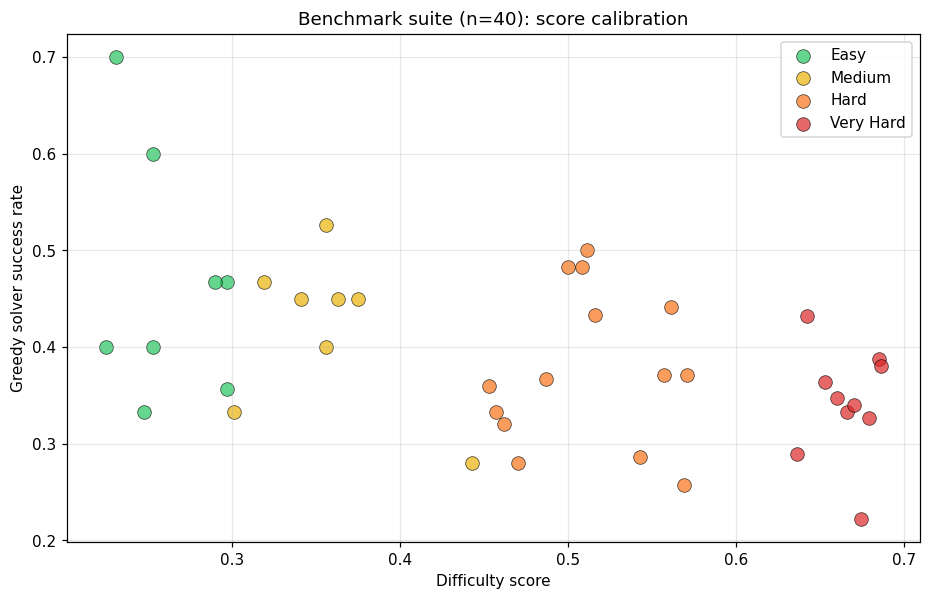

In [19]:
import pandas as pd

df = pd.DataFrame(manifest)
print("First 10 benchmark instances:")
print(df.head(10).to_string(index=False))
print(f"\n\nSuccess rate by difficulty class:")
print(df.groupby("class")["greedy_success_rate"].agg(["mean","std","count"]).round(3))

# Scatter
fig, ax = plt.subplots(figsize=(10, 6))
colors = {"Easy":"#22c55e", "Medium":"#eab308", "Hard":"#f97316", "Very Hard":"#dc2626"}
for cls_name in ["Easy", "Medium", "Hard", "Very Hard"]:
    sub = df[df["class"] == cls_name]
    if len(sub):
        ax.scatter(sub["score"], sub["greedy_success_rate"], s=80, alpha=0.7,
                   color=colors[cls_name], label=cls_name, edgecolor="black", lw=0.5)
ax.set_xlabel("Difficulty score"); ax.set_ylabel("Greedy solver success rate")
ax.set_title(f"Benchmark suite (n={len(df)}): score calibration")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

In [16]:
import shutil
shutil.make_archive("/content/benchmark_suite", "zip", "/content/benchmark_suite")
print("Zip created: /content/benchmark_suite.zip")
print("Download from the left sidebar (folder icon) → right-click the file → Download")

# Optional: also download via python
from google.colab import files
files.download("/content/benchmark_suite.zip")

Zip created: /content/benchmark_suite.zip
Download from the left sidebar (folder icon) → right-click the file → Download


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Conclusions

### Findings

**Difficulty score is empirically validated.** Across 75 validation instances, greedy solver success rate correlates negatively with the difficulty score: Pearson r = −0.580 (p = 5×10⁻⁸), Spearman ρ = −0.596 (p = 2×10⁻⁸). Mean success rate decreases monotonically across the four classes in the final benchmark:

| Class      | n  | Mean success | Std    |
|------------|----|--------------|--------|
| Easy       | 8  | 46.6%        | 12.6%  |
| Medium     | 8  | 42.0%        | 7.9%   |
| Hard       | 14 | 37.8%        | 8.0%   |
| Very Hard  | 10 | 34.2%        | 5.7%   |

Variance also tightens with difficulty (12.6% → 5.7%), meaning the score is more *consistent* on harder instances.

**GMM beats the baseline on parametric pattern recovery.** GMM achieves ~100× higher spatial log-likelihood (−0.05 vs −4.28) and halves temporal Wasserstein distance (0.18 vs 0.35). Spatial sliced-Wasserstein is essentially tied (0.28 vs 0.28) — both methods capture rough density, but only GMM gives accurate density *estimation*. BIC selected 2 spatial and 4 temporal components without manual tuning. Log-normal service times match reference within 3%.

**Thresholds were calibrated empirically.** Initial *a priori* thresholds (0.30 / 0.50 / 0.70) yielded zero Very Hard instances, so they were recalibrated to 0.30 / 0.45 / 0.60 from the observed distribution. The validation correlation was computed on a separate 75-instance set with the original scores, so recalibration does not contaminate the validity claim.

### Contributions

- Unified generator integrating dual-visit constraints, time-dependent travel, and time windows
- Two-tier road network with road-class-aware congestion (arterials hit harder by rush hour)
- Five-component difficulty score, empirically validated (r = −0.58, p < 10⁻⁷)
- 40-instance benchmark suite in JSON + CSV, spanning all four difficulty classes
- GMM-vs-baseline ML ablation with Wasserstein and log-likelihood metrics

### Limitations

- GMM did not improve spatial sliced-Wasserstein over the baseline; its advantage shows up in likelihood, not transport distance
- Reference dataset is itself synthetic — realism against real urban mobility data remains untested
- Greedy solver is intentionally simple; absolute success rates would shift with stronger solvers, though the monotone trend should hold
- Travel-time model uses departure-hour-multiplier approximation rather than FIFO-correct time-dependent Dijkstra

### Future work

- Calibrate spatial/temporal models against real anonymized healthcare data
- Stronger solver baselines (CP-SAT, metaheuristics) for tighter validation
- Online/stochastic variants with mid-day patient arrivals
- Public release on Zenodo for reuse by the operations-research community